In [1]:
import scarf

scarf.configure_output(level="WARNING", progress=False)

repository = scarf.cytebase.connect("scarf_docs")
ctrl_path = repository.download_dataset(
    name="kang_15K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
stim_path = repository.download_dataset(
    name="kang_14K_ifnb-pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)

ds_ctrl = scarf.DataStore(f"{ctrl_path}/data.zarr", nthreads=4)
ds_stim = scarf.DataStore(f"{stim_path}/data.zarr", nthreads=4)

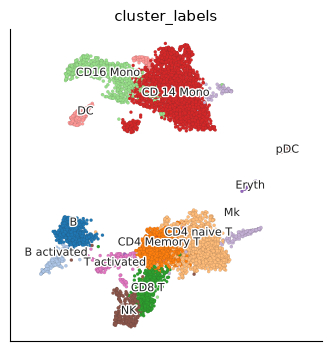

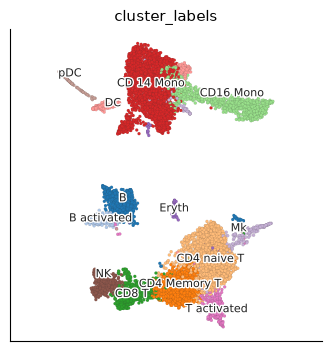

In [2]:
ds_ctrl.plots.embedding(
    layout_key="RNA_UMAP",
    color_by="cluster_labels",
)
ds_stim.plots.embedding(
    layout_key="RNA_UMAP",
    color_by="cluster_labels",
)

In [3]:
ds_ctrl.run_mapping(
    target_assay=ds_stim.RNA,
    target_name="stim",
    target_feat_key="hvgs_ctrl",
    save_k=5,
    missing_feature_policy="zero",
)

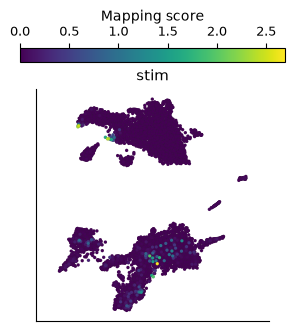

In [4]:
ds_ctrl.plots.mapping_score(
    target_name="stim",
    layout_key="RNA_UMAP",
)

In [5]:
transferred_labels = ds_ctrl.get_target_classes(
    target_name="stim",
    reference_class_group="cluster_labels",
    threshold_fraction=0.6,
)
ds_stim.cells.insert(
    "transferred_labels",
    transferred_labels.to_numpy(),
    overwrite=True,
)

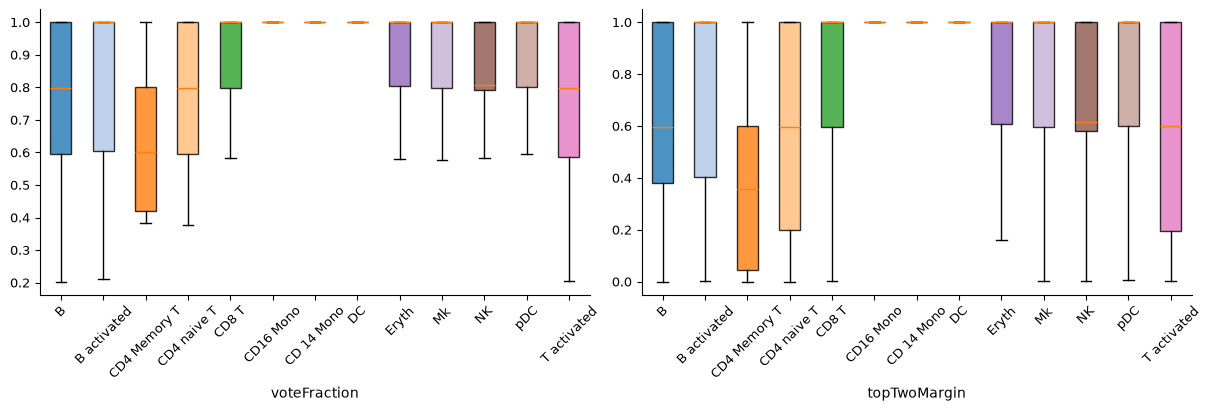

In [6]:
ds_ctrl.plots.mapping_evidence(
    target_name="stim",
    reference_class_group="cluster_labels",
    target_groups=ds_stim.cells.fetch("cluster_labels"),
    metrics=("voteFraction", "topTwoMargin"),
    kind="box",
    threshold_fraction=0.6,
    figsize=(12, 4),
)

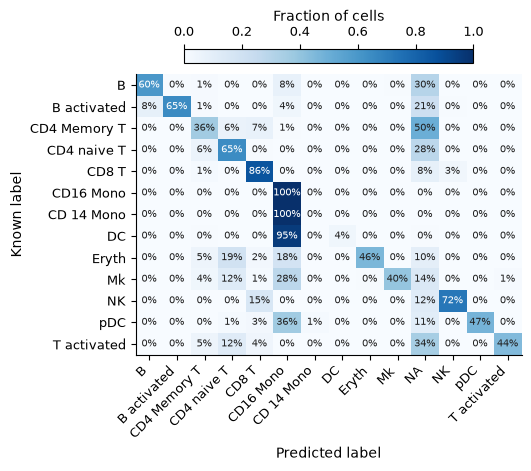

In [7]:
ds_ctrl.plots.mapping_confusion(
    target_name="stim",
    reference_class_group="cluster_labels",
    known_labels=ds_stim.cells.fetch("cluster_labels"),
    normalize="true",
    threshold_fraction=0.6,
)

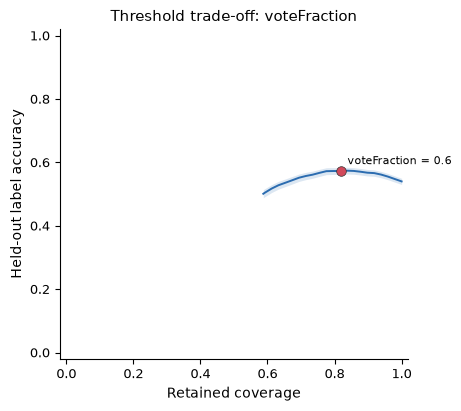

In [8]:
ds_ctrl.plots.mapping_calibration(
    target_name="stim",
    reference_class_group="cluster_labels",
    known_labels=ds_stim.cells.fetch("cluster_labels"),
    metric="voteFraction",
    chosen_threshold=0.6,
)

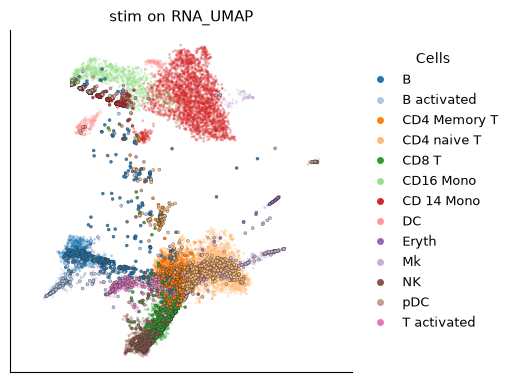

In [9]:
ds_ctrl.plots.mapping_projection(
    target_name="stim",
    reference_layout_key="RNA_UMAP",
    reference_groups="cluster_labels",
    target_groups=ds_stim.cells.fetch("cluster_labels"),
    ref_name="control",
)